# Retail Sales Intelligence
## Data Loading & Understanding

Author: Moh Bou
Project: Retail Sales Intelligence

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualization style
sns.set_style("whitegrid")

# show all columns
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [3]:
file_path = "../data/online+retail/Online Retail.xlsx"

df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Dataset Overview

In [4]:
df.shape

(541909, 8)

In [5]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cust

In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
def check_negative_numbers(df, column_name):
    """
    Checks if a column contains negative numbers, counts them, and prints the rows.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The DataFrame to check
    column_name : str
        The name of the column to check for negative numbers
    """
    
    # Check if column exists
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found in DataFrame")
        print(f"Available columns: {list(df.columns)}")
        return
    
    # Check for negative numbers
    negative_mask = df[column_name] < 0
    negative_count = negative_mask.sum()
    negative_rows = df[negative_mask]
    
    # Print results
    print(f"\n{'='*50}")
    print(f"ANALYSIS FOR COLUMN: '{column_name}'")
    print(f"{'='*50}")
    print(f"Total rows in DataFrame: {len(df)}")
    print(f"Rows with negative numbers: {negative_count}")
    print(f"Percentage negative: {(negative_count/len(df)*100):.2f}%" if len(df) > 0 else "N/A")
    
    if negative_count > 0:
        print(f"\n{'-'*50}")
        print("ROWS WITH NEGATIVE NUMBERS:")
        print(f"{'-'*50}")
        print(negative_rows)
        
        # Optional: Show just the index and value for quick reference
        print(f"\n{'-'*50}")
        print("SUMMARY (Index → Value):")
        print(f"{'-'*50}")
        for idx, value in negative_rows[column_name].items():
            print(f"  Row {idx}: {value}")
    else:
        print(f"\n✓ No negative numbers found in '{column_name}'")
    
    print(f"\n{'='*50}\n")
    
    return negative_rows

In [8]:
negative_number = check_negative_numbers(df,"UnitPrice")


ANALYSIS FOR COLUMN: 'UnitPrice'
Total rows in DataFrame: 541909
Rows with negative numbers: 2
Percentage negative: 0.00%

--------------------------------------------------
ROWS WITH NEGATIVE NUMBERS:
--------------------------------------------------
       InvoiceNo StockCode      Description  Quantity         InvoiceDate  \
299983   A563186         B  Adjust bad debt         1 2011-08-12 14:51:00   
299984   A563187         B  Adjust bad debt         1 2011-08-12 14:52:00   

        UnitPrice  CustomerID         Country  
299983  -11062.06         NaN  United Kingdom  
299984  -11062.06         NaN  United Kingdom  

--------------------------------------------------
SUMMARY (Index → Value):
--------------------------------------------------
  Row 299983: -11062.06
  Row 299984: -11062.06




In [ ]:
df.isnull().sum()

In [10]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

## checking for negative numbers

In [18]:
dups = df[df["StockCode"].duplicated(keep=False)]
print(f"\nDuplicate values in StockCode:")
print(dups.head(5
               ))


Duplicate values in StockCode:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


df = df[df["UnitPrice"] > 0]

In [28]:
df.duplicated().sum()

np.int64(0)

## 1. Create Working Copy

We create a copy of the dataset to preserve the original raw data.

In [33]:
df_clean = df.copy()

## 2. Remove Accounting Adjustments

Rows with negative UnitPrice represent accounting corrections
and not real sales transactions.

In [34]:
df_clean = df_clean[df_clean["UnitPrice"] > 0]

## 3. Identify Product Returns

Negative quantities indicate returned items.

In [35]:
returns = df_clean[df_clean["Quantity"] < 0]

returns.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [36]:
returns.shape

(9251, 8)

## 4. Remove Returns

For this analysis, we focus only on completed sales transactions.
Returned items are removed.

In [37]:
df_clean = df_clean[df_clean["Quantity"] > 0]

## 5. Handle Missing Customer IDs

CustomerID is required for customer behavior analysis.
Rows without customers are removed.

In [38]:
df_clean = df_clean.dropna(subset=["CustomerID"])

## 6. Remove Duplicate Rows

Removing fully duplicated transactions.

In [39]:
df_clean = df_clean.drop_duplicates()

## 7. Convert Data Types

Ensure InvoiceDate is in datetime format.

In [40]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

## 8. Create Revenue Column

Revenue is calculated as Quantity multiplied by UnitPrice.

In [41]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

## 9. Final Dataset Overview

Verify dataset after cleaning.

In [42]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   Revenue      392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 30.0+ MB


In [43]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [44]:
df_clean.shape

(392692, 9)

## Product Analysis — Top Selling Products

Identify products with the highest total quantity sold.

In [48]:
top_products_qty = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_qty

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

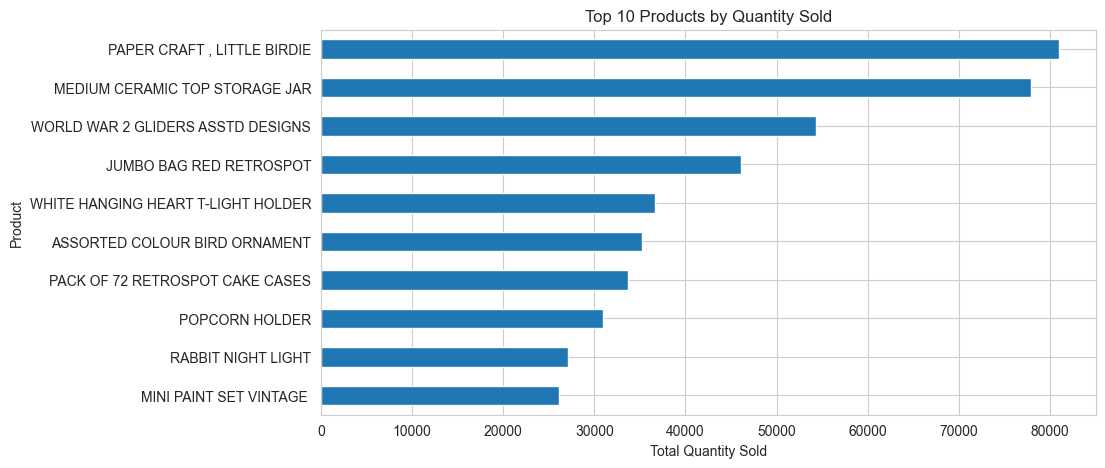

In [49]:
plt.figure(figsize=(10,5))

top_products_qty.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.show()

## Product Analysis — Top Products by Revenue

Identify products generating the highest total revenue.
Revenue = Quantity × UnitPrice.

In [50]:
top_products_revenue = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

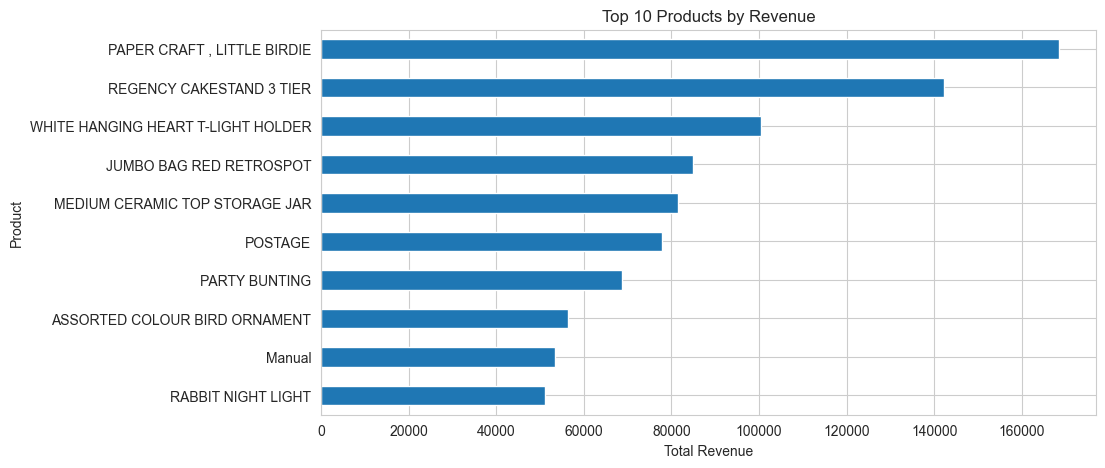

In [51]:
plt.figure(figsize=(10,5))

top_products_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.show()

## Initial Insight

Products generating the highest revenue are not always the most frequently sold.
Higher-priced items may contribute more to total income despite lower sales volume.

## Product Performance Comparison

Combine quantity sold and revenue generated for each product.

In [52]:
product_performance = (
    df_clean.groupby("Description")
    .agg({
        "Quantity": "sum",
        "Revenue": "sum"
    })
    .sort_values("Revenue", ascending=False)
)

product_performance.head(10)

,Quantity,Revenue
Description,,
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
REGENCY CAKESTAND 3 TIER,12374,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10
JUMBO BAG RED RETROSPOT,46078,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
POSTAGE,3120,77803.96
PARTY BUNTING,15279,68785.23
ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03
Manual,6933,53419.93


## Popularity vs Revenue Relationship

Analyze whether frequently sold products generate higher revenue.

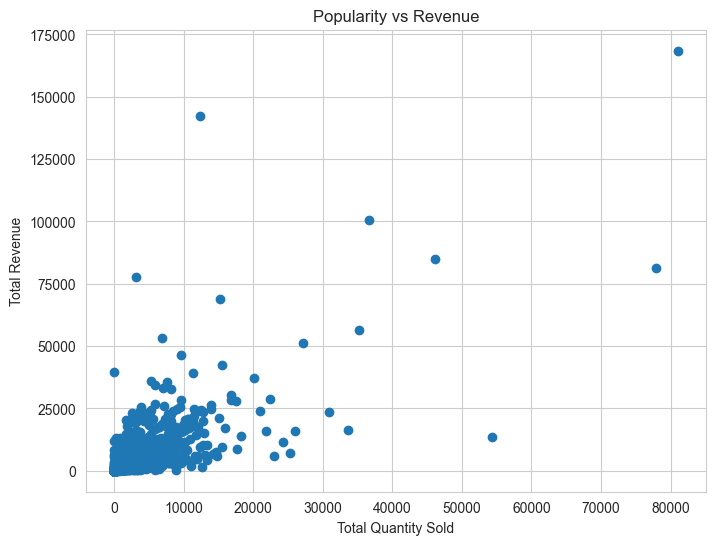

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    product_performance["Quantity"],
    product_performance["Revenue"]
)

plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")
plt.title("Popularity vs Revenue")

plt.show()

## High Value Products

Products generating above-average revenue.

In [54]:
avg_revenue = product_performance["Revenue"].mean()

high_value_products = product_performance[
    product_performance["Revenue"] > avg_revenue
]

high_value_products.head(10)

,Quantity,Revenue
Description,,
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
REGENCY CAKESTAND 3 TIER,12374,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10
JUMBO BAG RED RETROSPOT,46078,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
POSTAGE,3120,77803.96
PARTY BUNTING,15279,68785.23
ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03
Manual,6933,53419.93


## Business Insight

Not all popular products generate high revenue.
Some lower-volume products contribute disproportionately to total income,
indicating potential premium or high-margin items.

## Customer Analysis — Customer Revenue

Calculate total revenue generated by each customer.

In [55]:
customer_revenue = (
    df_clean.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

## Top Customers by Revenue

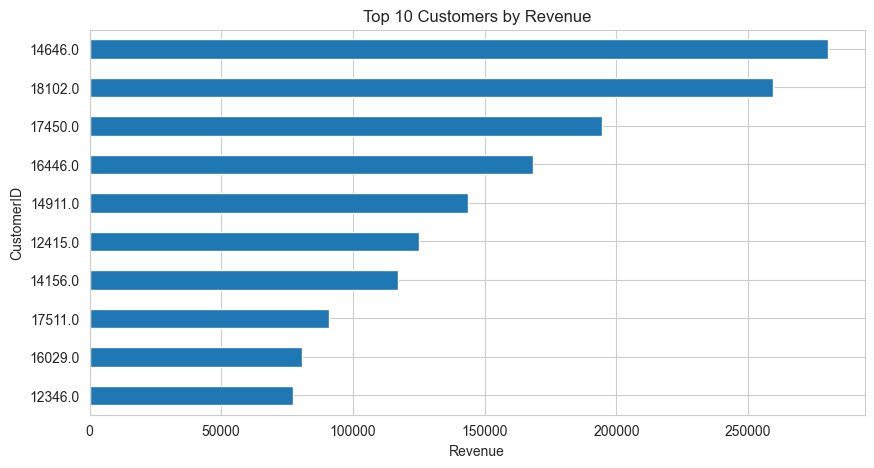

In [56]:
plt.figure(figsize=(10,5))

customer_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("CustomerID")

plt.show()

## Customer Revenue Distribution

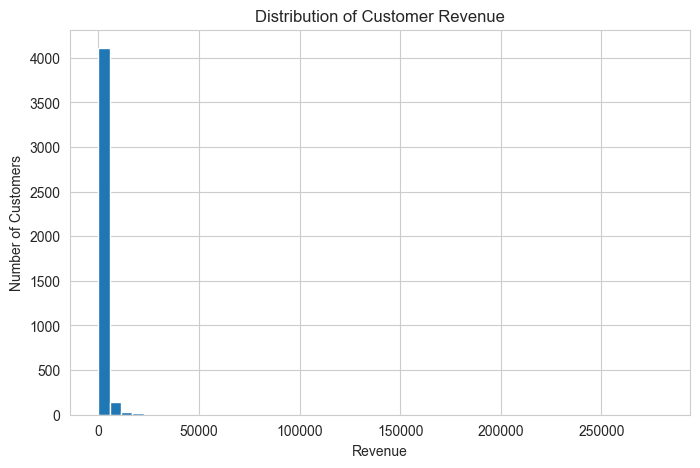

In [57]:
plt.figure(figsize=(8,5))

plt.hist(customer_revenue, bins=50)

plt.title("Distribution of Customer Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Customers")

plt.show()

## Pareto Analysis (80/20 Rule)

Identify how many customers generate most of the revenue.

In [58]:
# cumulative revenue percentage
cum_revenue = customer_revenue.cumsum()
total_revenue = customer_revenue.sum()

pareto = cum_revenue / total_revenue

pareto.head()

CustomerID
14646.0    0.031529
18102.0    0.060746
17450.0    0.082619
16446.0    0.101576
14911.0    0.117747
Name: Revenue, dtype: float64

## Business Insight

Revenue distribution is highly concentrated among a small group of customers.
This suggests that customer retention and loyalty strategies should focus
on high-value customers.

## Time Feature Engineering

Extract useful time components from InvoiceDate.

In [ ]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

df_clean.head()

## Monthly Revenue Trend
Analyze how revenue changes across months.

In [60]:
monthly_revenue = (
    df_clean.groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: Revenue, dtype: float64

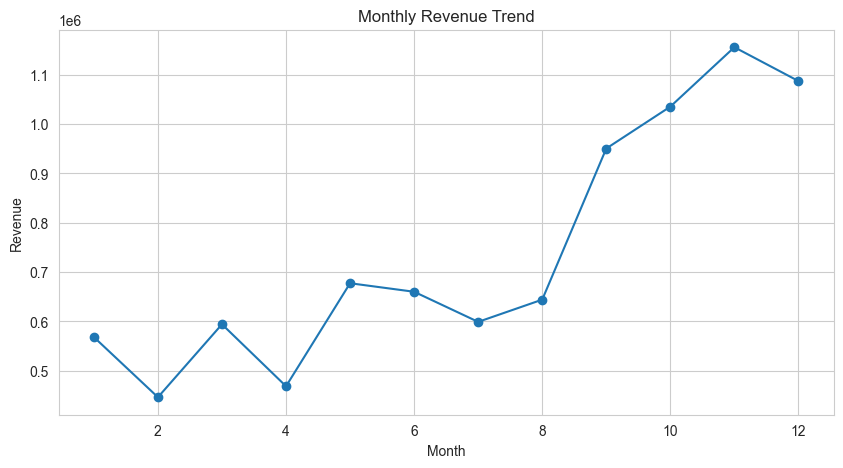

In [61]:
plt.figure(figsize=(10,5))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

## Revenue by Day of Week
Identify best-performing weekdays.

In [67]:
df_clean.groupby("DayOfWeek")["Revenue"].count()

DayOfWeek
Friday       54222
Monday       64231
Sunday       61212
Thursday     79243
Tuesday      65744
Wednesday    68040
Name: Revenue, dtype: int64

In [69]:
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

revenue_by_day = (
    df_clean.groupby("DayOfWeek")["Revenue"]
    .sum()
    .reindex(day_order,fill_value=0)
)

revenue_by_day

DayOfWeek
Monday       1363604.401
Tuesday      1697733.801
Wednesday    1584283.830
Thursday     1973015.730
Friday       1483080.811
Saturday           0.000
Sunday        785490.321
Name: Revenue, dtype: float64

## Revenue by Hour
Identify peak shopping hours.

In [63]:
revenue_by_hour = (
    df_clean.groupby("Hour")["Revenue"]
    .sum()
)

revenue_by_hour

Hour
6           4.250
7       31059.210
8      281997.790
9      842392.341
10    1259267.591
11    1101177.600
12    1373695.390
13    1168724.200
14     991992.821
15     963559.680
16     467380.560
17     233811.591
18     104744.990
19      48568.400
20      18832.480
Name: Revenue, dtype: float64

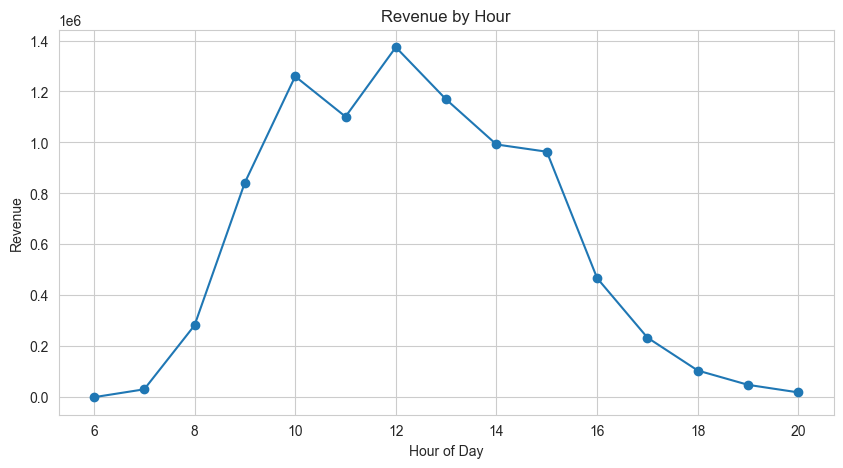

In [64]:
plt.figure(figsize=(10,5))

revenue_by_hour.plot(kind="line", marker="o")

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")

plt.show()

## Time-Based Insights

Sales activity varies significantly across time.
Identifying peak months, days, and hours can help optimize
marketing campaigns, staffing, and inventory planning.

## 🌍 Revenue Analysis by Country

In [70]:
# Revenue by Country
revenue_by_country = (
    df_clean
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_country.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

## Average Revenue per Customer per Country

In [75]:
country_customer_revenue = (
    df_clean
    .groupby(["Country", "CustomerID"])["Revenue"]
    .sum()
    .reset_index()
)

avg_revenue_country = (
    country_customer_revenue
    .groupby("Country")["Revenue"]
    .mean()
    .sort_values(ascending=False)
)

avg_revenue_country.head(10)

Country
EIRE           88420.820000
Netherlands    31716.260000
Singapore      21279.290000
Australia      15383.756667
Sweden          4795.978750
Japan           4677.046250
Iceland         4310.000000
Norway          3616.544000
Switzerland     2687.807143
Germany         2432.748936
Name: Revenue, dtype: float64

## 👤 Customer Segmentation Using RFM Analysis

In [71]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

## 📊 Correlation Analysis Between RFM Metrics

In [72]:
rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [73]:
rfm.corr()

,Recency,Frequency,Monetary
Recency,1.000000,-0.260578,-0.121831
Frequency,-0.260578,1.000000,0.552780
Monetary,-0.121831,0.552780,1.000000


## 🎯 RFM Scoring and Customer Segmentation

In [74]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112
